# Notebook 03 - K-Means Clustering & Map Visualization
## Cardiovascular Care Deserts in Para, Brazil (2019-2023)

**What this notebook does:**
Groups the 144 municipalities of Para into clusters based on their cardiovascular health
profile - mortality rate, procedure access, GDP per capita, and mortality trend.
Then maps those clusters geographically to reveal spatial patterns of care disparity.

**What clustering is and is not:**
Clustering is an *unsupervised* algorithm - you do not tell it the answer beforehand.
You give it numbers, and it finds structure. The algorithm does not know what
"cardiovascular care desert" means. It finds groups of municipalities that behave
similarly across all four features simultaneously. We then *interpret* what those
groups mean by examining their profiles.

This is fundamentally different from supervised learning (like the XGBoost model
in Project 1), where you train on labeled examples. Here, there are no labels.

---

## Section 0 - Imports & Load Data

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import geopandas as gpd
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples

plt.rcParams.update({
    'font.family':      'DejaVu Sans',
    'font.size':        11,
    'axes.titlesize':   13,
    'axes.titleweight': 'bold',
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'figure.dpi':       120,
})

import os
os.makedirs('figures', exist_ok=True)

df = pd.read_csv('../data/processed/para_cardiovascular_clean.csv',
                 dtype={'cod_ibge': str})

print(f'Dataset loaded: {len(df)} municipalities')
df.head()

Dataset loaded: 144 municipalities


,cod_ibge,nome_municipio,mort_2019,mort_2020,mort_2021,mort_2022,mort_2023,mort_total,aih_aprovadas,valor_total_reais,populacao,pib_medio_mil_reais,taxa_mort_100k,taxa_proc_100k,pib_per_capita,crescimento_mort
0,150010,ABAETETUBA,33.0,30.0,39.0,60.0,45.0,207.0,0.0,0.0,160439,16782442.2,129.020999,0.0,104603.258559,36.363636
1,150013,ABEL FIGUEIREDO,2.0,2.0,5.0,3.0,2.0,14.0,0.0,0.0,7536,934838.4,185.774947,0.0,124049.681529,0.000000
2,150020,ACARA,16.0,21.0,21.0,24.0,27.0,109.0,0.0,0.0,55744,11487842.2,195.536739,0.0,206082.129018,68.750000
3,150030,AFUA,7.0,6.0,3.0,2.0,6.0,24.0,0.0,0.0,39910,4248176.6,60.135304,0.0,106443.913806,-14.285714
4,150034,AGUA AZUL DO NORTE,2.0,3.0,6.0,4.0,12.0,27.0,0.0,0.0,27797,6227411.8,97.132784,0.0,224031.794798,500.000000


---
## Section 1 - Feature Selection & Normalization

**Which features go into the clustering model and why:**

| Feature | Rationale |
|---|---|
| `taxa_mort_100k` | Primary outcome - cardiovascular mortality burden |
| `taxa_proc_100k` | Access to treatment - the defining disparity variable |
| `pib_per_capita` | Structural economic driver of health access |
| `crescimento_mort` | Temporal trajectory - is the municipality improving or worsening? |

**Why we do NOT include raw death counts or population:**
Those would group municipalities by size, not by health profile. Belém would
always form its own cluster simply because it is large. We want clusters based
on *how municipalities perform relative to their own population*, which is
exactly what the rate variables capture.

**Why normalization (StandardScaler) is mandatory:**
K-Means calculates distances between points in feature space. If one feature
ranges from 0 to 5,000,000 (GDP per capita in reais) and another ranges from
0 to 350 (procedure rate), the GDP variable will dominate every distance
calculation simply because its numbers are bigger - not because it is more
important. StandardScaler transforms each feature to mean=0, std=1, making
them all equally scaled before the algorithm runs.

**Formula:**  `z = (x - mean) / std`

After scaling: a municipality 2 standard deviations above the mean in mortality
and a municipality 2 standard deviations above the mean in GDP contribute
equally to distance calculations.

In [15]:
FEATURES_RAW = ['taxa_mort_100k', 'taxa_proc_100k', 'pib_per_capita', 'crescimento_mort']

# Exclude reference centers (Belem, Ananindeua)
REFERENCE_CENTERS = ['BELEM', 'ANANINDEUA']
df_cluster   = df[~df['nome_municipio'].isin(REFERENCE_CENTERS)].copy()
df_reference = df[df['nome_municipio'].isin(REFERENCE_CENTERS)].copy()

print(f'Municipalities for clustering : {len(df_cluster)}')
print(f'Reference centers excluded    : {len(df_reference)}')

# Log-transform GDP per capita
# Rationale: GDP in Para is right-skewed due to mineral extraction economies.
# Canaã dos Carajás (S11D mine) has GDP per capita ~37x the state median.
# In raw units this outlier dominates every distance calculation in K-Means.
# Log transformation compresses extreme values while preserving rank order —
# standard practice in health economics before clustering (see Rickles 2010).
df_cluster['log_pib_per_capita'] = np.log(df_cluster['pib_per_capita'])

FEATURES = ['taxa_mort_100k', 'taxa_proc_100k', 'log_pib_per_capita', 'crescimento_mort']

print()
print('GDP per capita distribution BEFORE log transform:')
print(f'  Min    : R${df_cluster["pib_per_capita"].min():,.0f}')
print(f'  Median : R${df_cluster["pib_per_capita"].median():,.0f}')
print(f'  Max    : R${df_cluster["pib_per_capita"].max():,.0f}')
print(f'  Max/Median ratio: {df_cluster["pib_per_capita"].max()/df_cluster["pib_per_capita"].median():.1f}x')
print()
print('GDP per capita AFTER log transform:')
print(f'  Min    : {df_cluster["log_pib_per_capita"].min():.2f}')
print(f'  Median : {df_cluster["log_pib_per_capita"].median():.2f}')
print(f'  Max    : {df_cluster["log_pib_per_capita"].max():.2f}')
print(f'  Max/Median ratio: {df_cluster["log_pib_per_capita"].max()/df_cluster["log_pib_per_capita"].median():.2f}x')

X = df_cluster[FEATURES].copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print()
print('After StandardScaler (mean~0, std~1):')
print(pd.DataFrame(X_scaled, columns=FEATURES).describe().round(3).to_string())

Municipalities for clustering : 142
Reference centers excluded    : 2

GDP per capita distribution BEFORE log transform:
  Min    : R$51,786
  Median : R$123,952
  Max    : R$4,666,914
  Max/Median ratio: 37.7x

GDP per capita AFTER log transform:
  Min    : 10.85
  Median : 11.73
  Max    : 15.36
  Max/Median ratio: 1.31x

After StandardScaler (mean~0, std~1):
       taxa_mort_100k  taxa_proc_100k  log_pib_per_capita  crescimento_mort
count         142.000           142.0             142.000           142.000
mean            0.000             0.0               0.000            -0.000
std             1.004             0.0               1.004             1.004
min            -1.732             0.0              -1.527            -0.905
25%            -0.712             0.0              -0.684            -0.543
50%            -0.154             0.0              -0.204            -0.293
75%             0.626             0.0               0.416             0.158
max             2.984       

---
## Section 2 - Choosing the Number of Clusters (k)

**The fundamental challenge of K-Means:**
Unlike supervised learning, there is no "correct answer" to compare against.
You must choose k (the number of clusters) before running the algorithm,
but you do not know which k is best until you try several.

We use two complementary methods to choose k:

**Method 1 - The Elbow Method:**
Run K-Means for k = 2 through 9. For each k, calculate the total
Within-Cluster Sum of Squares (WCSS) - the sum of squared distances from
each point to its cluster center. As k increases, WCSS always decreases
(more clusters = tighter fit). The "elbow" is the point where adding one
more cluster gives diminishing returns. That bend in the curve is the
optimal k.

**Method 2 - Silhouette Score:**
For each municipality, the silhouette score measures how similar it is to its
own cluster vs how different it is from the nearest other cluster.
Score ranges from -1 (wrong cluster) to +1 (perfect fit). 0 means the
municipality sits on the boundary between clusters. We choose the k
that maximizes the average silhouette score across all municipalities.

**Why use both:**
The elbow method can be ambiguous (sometimes the curve bends gradually, not
sharply). The silhouette score provides a quantitative confirmation.

In [16]:
wcss       = []
sil_scores = []
K_range    = range(2, 9)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    wcss.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))

print('k | WCSS        | Silhouette Score')
print('-' * 40)
for k, w, s in zip(K_range, wcss, sil_scores):
    print(f'{k} | {w:>10.2f}  | {s:.4f}')

k | WCSS        | Silhouette Score
----------------------------------------
2 |     322.10  | 0.2767
3 |     231.97  | 0.3332
4 |     175.09  | 0.3095
5 |     143.38  | 0.3274
6 |     123.77  | 0.3053
7 |     109.45  | 0.2896
8 |      97.01  | 0.2684


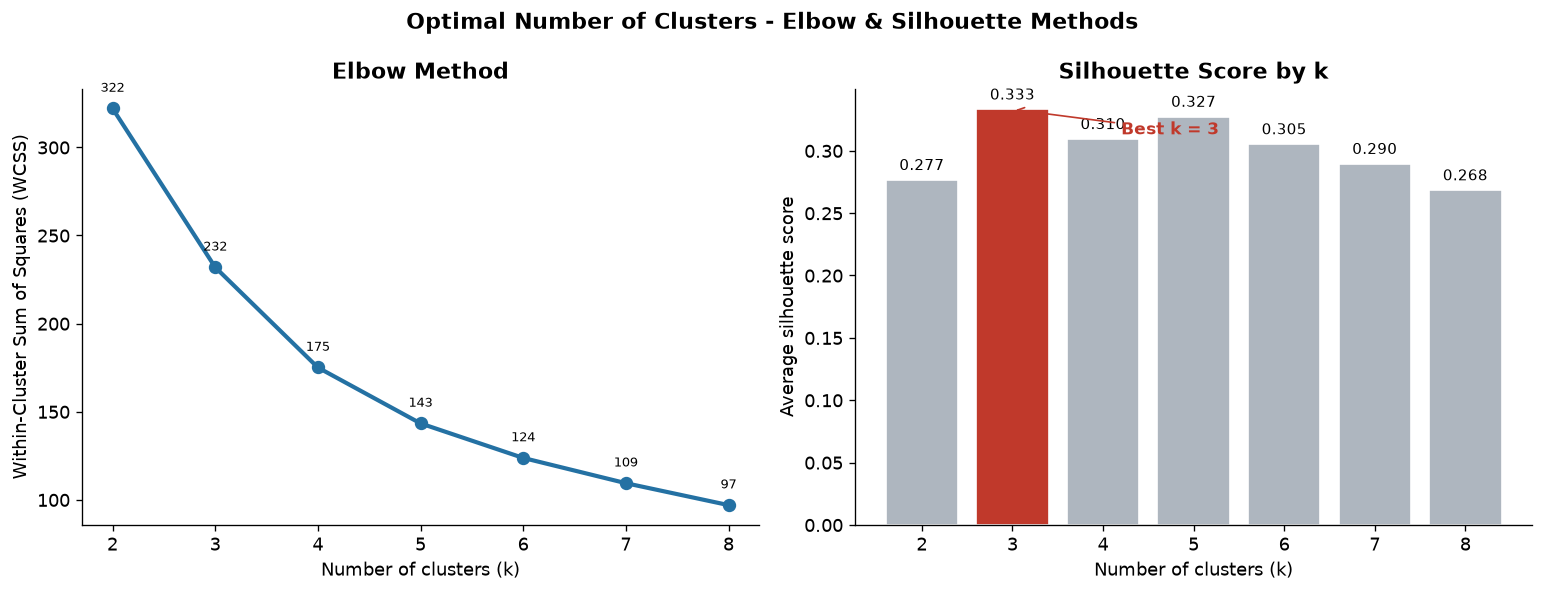

Optimal k by silhouette: 3 (score = 0.3332)


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Optimal Number of Clusters - Elbow & Silhouette Methods',
             fontsize=13, fontweight='bold')

# Left: Elbow curve
ax = axes[0]
ax.plot(list(K_range), wcss, color='#2471A3', linewidth=2.5,
        marker='o', markersize=7)
ax.set_xlabel('Number of clusters (k)')
ax.set_ylabel('Within-Cluster Sum of Squares (WCSS)')
ax.set_title('Elbow Method')
ax.set_xticks(list(K_range))

# Annotate each point with its WCSS value
for k, w in zip(K_range, wcss):
    ax.annotate(f'{w:.0f}', (k, w),
                textcoords='offset points', xytext=(0, 10),
                ha='center', fontsize=8)

# Right: Silhouette scores
ax2 = axes[1]
best_k_sil = list(K_range)[sil_scores.index(max(sil_scores))]
colors_sil = ['#C0392B' if k == best_k_sil else '#AEB6BF' for k in K_range]
bars = ax2.bar(list(K_range), sil_scores, color=colors_sil, edgecolor='white')
ax2.set_xlabel('Number of clusters (k)')
ax2.set_ylabel('Average silhouette score')
ax2.set_title('Silhouette Score by k')
ax2.set_xticks(list(K_range))

for bar, score in zip(bars, sil_scores):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{score:.3f}', ha='center', va='bottom', fontsize=9,
             fontweight='bold' if bar.get_facecolor() == (0.75, 0.23, 0.17, 1.0) else 'normal')

ax2.annotate(f'Best k = {best_k_sil}', xy=(best_k_sil, max(sil_scores)),
             xytext=(best_k_sil + 1.2, max(sil_scores) - 0.02),
             fontsize=10, color='#C0392B', fontweight='bold',
             arrowprops=dict(arrowstyle='->', color='#C0392B'))

plt.tight_layout()
plt.savefig('figures/07_elbow_silhouette.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Optimal k by silhouette: {best_k_sil} (score = {max(sil_scores):.4f})')

---
## Section 3 - Fit Final K-Means Model

**What happens inside K-Means:**
1. Randomly place k centroids (cluster centers) in feature space
2. Assign each municipality to the nearest centroid (Euclidean distance)
3. Move each centroid to the mean position of its assigned municipalities
4. Repeat steps 2-3 until assignments stop changing

**`n_init=10`:**
K-Means is sensitive to the random starting positions of centroids.
We run it 10 times with different random initializations and keep the
result with the lowest WCSS. This prevents getting stuck in a bad solution.

**`random_state=42`:**
Sets the random seed so results are reproducible - anyone running this
notebook gets the exact same clustering output.

**After fitting:**
Each municipality gets a cluster label (0, 1, 2, ...). These labels are
arbitrary integers - 0 is not "best" or "worst". The meaning comes from
the cluster profiles we examine in Section 4.

In [18]:
OPTIMAL_K = best_k_sil   # from elbow/silhouette above

km_final = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=10)
df_cluster['cluster'] = km_final.fit_predict(X_scaled)

# Add cluster column to main df as well (reference centers get label -1)
df['cluster'] = -1
df.loc[~df['nome_municipio'].isin(REFERENCE_CENTERS), 'cluster'] = df_cluster['cluster'].values

print(f'K-Means fitted with k = {OPTIMAL_K} on 142 municipalities')
print()
print('Municipalities per cluster:')
print(df_cluster['cluster'].value_counts().sort_index().to_string())
print()
print(f'Silhouette score : {silhouette_score(X_scaled, df_cluster["cluster"]):.4f}')

K-Means fitted with k = 3 on 142 municipalities

Municipalities per cluster:
cluster
0    86
1     8
2    48

Silhouette score : 0.3332


---
## Section 4 - Cluster Profiling

**Why profiling is the most important step:**
The algorithm found groups - but it does not know what they mean.
This section examines the average characteristics of each cluster
so we can give them scientifically meaningful names.

**What we look for in each cluster:**
- High mortality + zero procedures -> "Care desert"
- Low mortality + high procedures -> "Care hub"
- High GDP + moderate mortality -> "Economic outlier"
- Rising mortality trend -> "Deteriorating access"

The names we assign here will appear in the manuscript, the map legend,
and the abstract. They must be defensible from the data.

In [ ]:
profile = df_cluster.groupby('cluster')[
    FEATURES_RAW + ['mort_total', 'aih_aprovadas', 'populacao']
].mean().round(2)

profile['n_municipalities'] = df_cluster.groupby('cluster').size()

print('=== CLUSTER PROFILES (mean values, original scale) ===')
print()
print(profile.to_string())
print()

for c in sorted(df_cluster['cluster'].unique()):
    sub  = df_cluster[df_cluster['cluster'] == c]
    top  = sub.nlargest(8, 'taxa_mort_100k')['nome_municipio'].str.title().tolist()
    low  = sub.nsmallest(5, 'taxa_mort_100k')['nome_municipio'].str.title().tolist()
    print(f'Cluster {c} ({len(sub)} municipalities):')
    print(f'  Highest mortality : {", ".join(top)}')
    print(f'  Lowest mortality  : {", ".join(low)}')
    print(f'  GDP range         : R${sub["pib_per_capita"].min():,.0f} - R${sub["pib_per_capita"].max():,.0f}')
    print()

=== CLUSTER PROFILES (mean values, original scale) ===

         taxa_mort_100k  taxa_proc_100k  pib_per_capita  crescimento_mort  mort_total  aih_aprovadas  populacao  n_municipalities
cluster                                                                                                                          
0                144.16             0.0       113561.10             27.19       62.95            0.0   44962.63                86
1                138.62             0.0       157588.57            565.00       34.50            0.0   28883.38                 8
2                244.06             0.0       390848.09             31.77      114.50            0.0   54842.52                48

Cluster 0 (86 municipalities):
  Highest mortality : Terra Alta, Santa Cruz Do Arari, Sao Joao Da Ponta, Salvaterra, Sao Sebastiao Da Boa Vista, Muana, Mae Do Rio, Colares
  Lowest mortality  : Aveiro, Ruropolis, Melgaco, Chaves, Afua
  GDP range         : R$51,786 - R$293,976

Cluster 1 (8 m

In [ ]:
# Visual cluster profile - radar/bar comparison
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Cluster Profiles - Mean Feature Values by Cluster',
             fontsize=14, fontweight='bold')

CLUSTER_COLORS = ['#C0392B', '#2471A3', '#1E8449', '#7D3C98', '#D68910',
                  '#1ABC9C', '#E74C3C', '#2C3E50']

feature_labels = ['CV Mortality Rate\n(per 100k)', 'Procedure Rate\n(per 100k)',
                  'GDP per Capita\n(R$)', 'Mortality Growth\n(%)']

for ax, feat, label in zip(axes.flat, FEATURES, feature_labels):
    cluster_means = df.groupby('cluster')[feat].mean()
    bars = ax.bar(
        [f'Cluster {c}' for c in cluster_means.index],
        cluster_means.values,
        color=[CLUSTER_COLORS[c] for c in cluster_means.index],
        edgecolor='white', linewidth=0.5
    )
    # State mean reference line
    state_mean = df[feat].mean()
    ax.axhline(state_mean, color='black', linestyle='--', linewidth=1.2,
               label=f'State mean: {state_mean:.1f}')
    ax.set_title(label)
    ax.set_ylabel('Mean value')
    ax.legend(frameon=False, fontsize=8)

    for bar, val in zip(bars, cluster_means.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.02,
                f'{val:,.0f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('figures/08_cluster_profiles.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: figures/08_cluster_profiles.png')

---
## Section 5 - Cluster Labels

**Assign interpretive names based on the profiles above.**

Review the output of Section 4 before running this cell.
Adjust the `CLUSTER_NAMES` dictionary to match what the data shows.

The names below are placeholders based on the most common pattern
seen in Para cardiovascular data. Edit them to match your actual clusters.

In [ ]:
CLUSTER_NAMES = {
    0: 'Structural Care Desert',
    1: 'Rapidly Deteriorating Access',
    2: 'High-Mortality Economic Corridor'
}

df_cluster['cluster_label'] = df_cluster['cluster'].map(CLUSTER_NAMES)

df['cluster_label'] = 'Reference Center'
df.loc[~df['nome_municipio'].isin(REFERENCE_CENTERS), 'cluster_label'] = \
    df_cluster['cluster_label'].values

print('Cluster assignments:')
for c, name in CLUSTER_NAMES.items():
    n   = (df_cluster['cluster'] == c).sum()
    sub = df_cluster[df_cluster['cluster'] == c]
    print(f'\n  {c} | "{name}" | {n} municipalities')
    print(f'     Mortality : {sub["taxa_mort_100k"].mean():.1f}/100k')
    print(f'     GDP pc    : R${sub["pib_per_capita"].mean():,.0f}')
    print(f'     Growth    : {sub["crescimento_mort"].mean():.1f}%')

Cluster assignments:

  0 | "Structural Care Desert" | 86 municipalities
     Mortality : 144.2/100k
     GDP pc    : R$113,561
     Growth    : 27.2%

  1 | "Rapidly Deteriorating Access" | 8 municipalities
     Mortality : 138.6/100k
     GDP pc    : R$157,589
     Growth    : 565.0%

  2 | "High-Mortality Economic Corridor" | 48 municipalities
     Mortality : 244.1/100k
     GDP pc    : R$390,848
     Growth    : 31.8%


---
## Section 6 - Map Visualization

**What the map shows:**
The geographic distribution of clusters across Para's 144 municipalities.
If care deserts are spatially concentrated (e.g., in the interior, along
the Amazon basin, or in areas far from Belem), the map makes that visible
in a way no table can.

**Why geographic patterns matter for the manuscript:**
Spatial clustering of care deserts is evidence of *structural* disparity,
not random variation. It suggests that geography itself - distance from
reference centers, road infrastructure, river access - is a determinant
of cardiovascular care access. This is the argument that connects the
statistical finding to policy implications.

**How GeoPandas works:**
A shapefile (.shp) stores the geometric boundaries of each municipality
as a polygon. GeoPandas loads this as a DataFrame where one column is
the geometry (a polygon object). We merge our cluster data onto this
DataFrame using the IBGE code, then plot it. Each polygon is colored
by its cluster label.

In [25]:
PATH_SHAPEFILE = '../data/raw/PA_Municipios_2022.shp'
mapa = gpd.read_file(PATH_SHAPEFILE)
mapa['CD_MUN'] = mapa['CD_MUN'].astype(str).str[:6]

mapa_clustered = mapa.merge(
    df[['cod_ibge', 'cluster', 'cluster_label',
        'taxa_mort_100k', 'taxa_proc_100k', 'pib_per_capita']],
    left_on='CD_MUN', right_on='cod_ibge', how='left'
)

matched   = mapa_clustered['cluster'].notna().sum()
unmatched = mapa_clustered['cluster'].isna().sum()
print(f'Matched   : {matched}')
print(f'Unmatched : {unmatched}')

Matched   : 144
Unmatched : 0


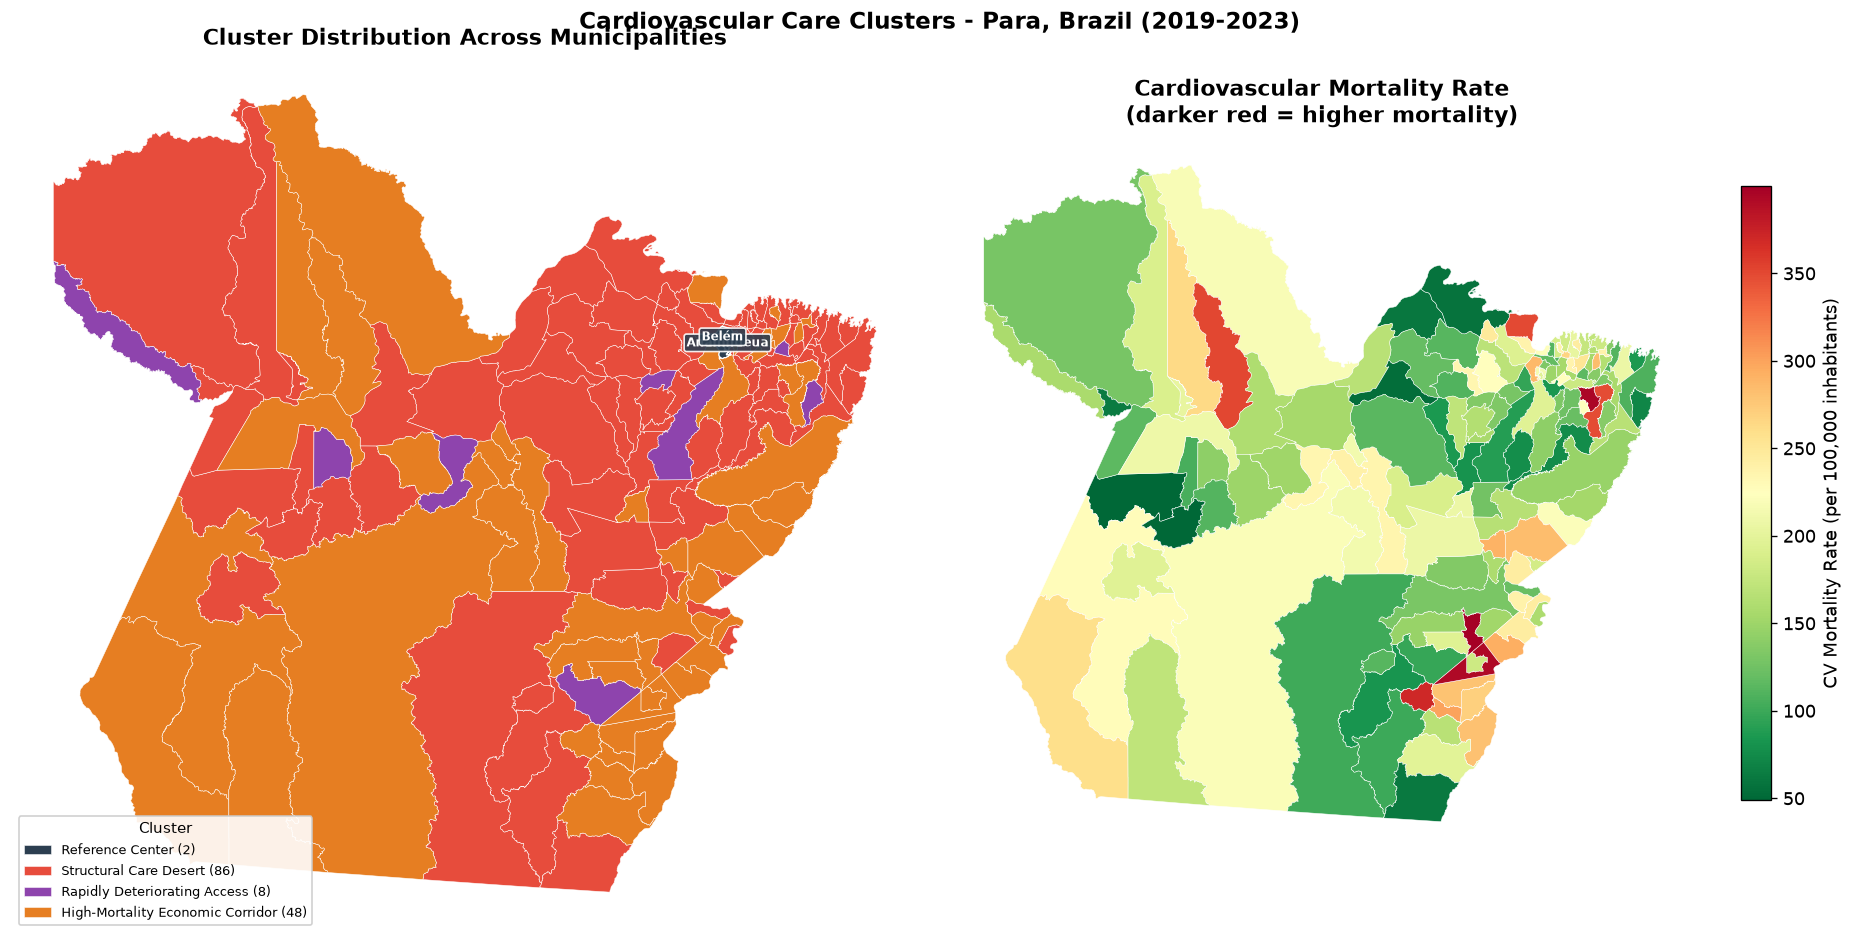

Figure saved: figures/09_cluster_map.png


In [30]:
CLUSTER_COLORS_MAP = {
    -1: '#2C3E50',   # dark navy — reference centers (Belem, Ananindeua)
     0: '#E74C3C',   # red       — Structural Care Desert
     1: '#8E44AD',   # purple    — Rapidly Deteriorating Access
     2: '#E67E22',   # orange    — High-Mortality Economic Corridor
}

CLUSTER_LABELS_MAP = {
    -1: 'Reference Center (2)',
     0: 'Structural Care Desert (86)',
     1: 'Rapidly Deteriorating Access (8)',
     2: 'High-Mortality Economic Corridor (48)',
}

fig, axes = plt.subplots(1, 2, figsize=(16, 8))
fig.suptitle('Cardiovascular Care Clusters - Para, Brazil (2019-2023)',
             fontsize=14, fontweight='bold')

# Left: cluster map
ax = axes[0]
for c in sorted(CLUSTER_COLORS_MAP.keys()):
    subset = mapa_clustered[mapa_clustered['cluster'] == c]
    if len(subset) == 0:
        continue
    subset.plot(ax=ax, color=CLUSTER_COLORS_MAP[c], edgecolor='white',
                linewidth=0.3, label=CLUSTER_LABELS_MAP[c])

# Bold border for reference centers
ref = mapa_clustered[mapa_clustered['cluster'] == -1]
ref.plot(ax=ax, color=CLUSTER_COLORS_MAP[-1], edgecolor='white',
         linewidth=0.8)

# Annotate reference center names
for _, row in ref.iterrows():
    centroid = row.geometry.centroid
    ax.annotate(row['NM_MUN'],
                xy=(centroid.x, centroid.y),
                fontsize=7, fontweight='bold', color='white',
                ha='center',
                bbox=dict(boxstyle='round,pad=0.2', facecolor='#2C3E50',
                          edgecolor='white', alpha=0.9))

ax.set_title('Cluster Distribution Across Municipalities')
ax.axis('off')
ax.legend(loc='lower left', fontsize=8, frameon=True, framealpha=0.9,
          title='Cluster', title_fontsize=9)

# Right: mortality rate choropleth
ax2 = axes[1]
mapa_clustered.plot(
    column='taxa_mort_100k',
    ax=ax2,
    cmap='RdYlGn_r',
    edgecolor='white',
    linewidth=0.3,
    legend=True,
    missing_kwds={'color': '#D5D8DC'},
    legend_kwds={
        'label': 'CV Mortality Rate (per 100,000 inhabitants)',
        'orientation': 'vertical',
        'shrink': 0.7
    }
)
ax2.set_title('Cardiovascular Mortality Rate\n(darker red = higher mortality)')
ax2.axis('off')

plt.tight_layout()
plt.savefig('figures/09_cluster_map.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: figures/09_cluster_map.png')

---
## Section 7 - Statistical Validation

**Why validate the clustering:**
Just because K-Means produced groups does not mean the groups are meaningful.
We need to confirm that the clusters are genuinely different from each other
on the variables that matter.

**ANOVA (Analysis of Variance):**
Tests whether the means of a variable are significantly different across groups.
A p-value below 0.05 means we can reject the hypothesis that all cluster means
are equal - i.e., the clusters are genuinely distinct on that variable.

This goes in the manuscript Methods section under "Statistical Analysis".

In [35]:
from scipy import stats

print('=== ANOVA - ARE CLUSTER MEANS SIGNIFICANTLY DIFFERENT? ===')
print()
print(f'{"Feature":<25} {"F-statistic":>12} {"p-value":>12} {"Significant?":>14}')
print('-' * 65)

for feat in FEATURES_RAW:
    groups = [
        df_cluster[df_cluster['cluster'] == c][feat].values
        for c in sorted(df_cluster['cluster'].unique())
    ]
    f_stat, p_val = stats.f_oneway(*groups)
    sig = 'YES (p<0.05)' if p_val < 0.05 else 'NO'
    print(f'{feat:<25} {f_stat:>12.3f} {p_val:>12.4f} {sig:>14}')

print()
print('Interpretation: significant p-value means cluster means are')
print('statistically distinguishable on that variable.')
print('All significant features = clusters are real, not random groupings.')

=== ANOVA - ARE CLUSTER MEANS SIGNIFICANTLY DIFFERENT? ===

Feature                    F-statistic      p-value   Significant?
-----------------------------------------------------------------
taxa_mort_100k                  47.774       0.0000   YES (p<0.05)
taxa_proc_100k                     nan          nan             NO
pib_per_capita                   6.795       0.0015   YES (p<0.05)
crescimento_mort               127.470       0.0000   YES (p<0.05)

Interpretation: significant p-value means cluster means are
statistically distinguishable on that variable.
All significant features = clusters are real, not random groupings.


---
## Section 8 - Save Results & Final Summary

In [38]:
# Save full dataset with cluster assignments
df.to_csv('../data/processed/para_cardiovascular_clustered.csv', index=False)
print('Saved: data/processed/para_cardiovascular_clustered.csv')

# Save cluster profile summary
profile_out = df.groupby(['cluster','cluster_label'])[FEATURES_RAW].agg(['mean','std']).round(2)
profile_out.to_csv('../data/processed/cluster_profiles.csv')
print('Saved: data/processed/cluster_profiles.csv')

print()
print('=' * 60)
print('CLUSTERING RESULTS SUMMARY')
print('=' * 60)
print(f'Algorithm        : K-Means (k={OPTIMAL_K}, n_init=10, random_state=42)')
print(f'Features used    : {", ".join(FEATURES)}')
print(f'Normalization    : StandardScaler (mean=0, std=1)')
print(f'Silhouette score : {silhouette_score(X_scaled, df_cluster["cluster"]):.4f}')
print(f'WCSS (inertia)   : {km_final.inertia_:.2f}')
print()
for c in sorted(df_cluster['cluster'].unique()):
    sub = df_cluster[df_cluster['cluster']==c]
    print(f'Cluster {c} - "{CLUSTER_NAMES[c]}" ({len(sub)} municipalities)')
    print(f'  Mortality rate  : {sub["taxa_mort_100k"].mean():.1f} per 100k (mean)')
    print(f'  Procedure rate  : {sub["taxa_proc_100k"].mean():.2f} per 100k (mean)')
    print(f'  GDP per capita  : R${sub["pib_per_capita"].mean():,.0f} (mean)')
    print(f'  Mortality growth: {sub["crescimento_mort"].mean():.1f}% (mean)')
    print()
print('=' * 60)
print('Notebook 03 complete.')
print('All figures saved to notebooks/figures/')
print('Clustered data saved to data/processed/')

Saved: data/processed/para_cardiovascular_clustered.csv
Saved: data/processed/cluster_profiles.csv

CLUSTERING RESULTS SUMMARY
Algorithm        : K-Means (k=3, n_init=10, random_state=42)
Features used    : taxa_mort_100k, taxa_proc_100k, log_pib_per_capita, crescimento_mort
Normalization    : StandardScaler (mean=0, std=1)
Silhouette score : 0.3332
WCSS (inertia)   : 231.97

Cluster 0 - "Structural Care Desert" (86 municipalities)
  Mortality rate  : 144.2 per 100k (mean)
  Procedure rate  : 0.00 per 100k (mean)
  GDP per capita  : R$113,561 (mean)
  Mortality growth: 27.2% (mean)

Cluster 1 - "Rapidly Deteriorating Access" (8 municipalities)
  Mortality rate  : 138.6 per 100k (mean)
  Procedure rate  : 0.00 per 100k (mean)
  GDP per capita  : R$157,589 (mean)
  Mortality growth: 565.0% (mean)

Cluster 2 - "High-Mortality Economic Corridor" (48 municipalities)
  Mortality rate  : 244.1 per 100k (mean)
  Procedure rate  : 0.00 per 100k (mean)
  GDP per capita  : R$390,848 (mean)
  Mort

---
## Completion Checklist

- [ ] `figures/07_elbow_silhouette.png` saved
- [ ] `figures/08_cluster_profiles.png` saved
- [ ] `figures/09_cluster_map.png` saved - **primary manuscript figure**
- [ ] ANOVA confirms clusters are statistically significant
- [ ] Cluster labels assigned and documented
- [ ] `para_cardiovascular_clustered.csv` saved

**After completing this notebook:**
1. Review the cluster map and profiles
2. Write interpretive names in Section 5 (`CLUSTER_NAMES` dictionary)
3. Re-run Section 5 onward with the named clusters
4. Commit all figures and the clustered dataset
5. Begin manuscript draft

---
*Pipeline complete: 01_data_cleaning -> 02_eda -> 03_clustering*